---
title: "Extreme Heat Risk in Pergamino"
subtitle: "Climate projections, current heat patterns, and policy recommendations"
author: "Nissim Lebovits"
date: "2025-11-26"
execute:
  cache: true
  freeze: auto
---

## Introduction

This cookbook demonstrates how to assess extreme heat risk in a city using open data. We apply the climate risk framework from Chapter 3 (exposure, vulnerability, hazard) to extreme heat in Pergamino, a city of approximately 100,000 people in Buenos Aires Province, Argentina.

You will learn how to:

- Query CMIP6 climate projections to understand how extreme heat days will change
- Calculate land surface temperature from Landsat imagery to identify current hotspots
- Map population exposure using multiple metrics and vulnerability using census data
- Connect findings to policy recommendations using robust decision-making principles

The analysis concludes with five policy recommendations that work across multiple climate scenarios—an application of the robust decision-making framework from Chapter 4.

## Setup

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import duckdb
import requests
import warnings
import os
import zipfile

from io import BytesIO
from pathlib import Path
from rasterio.features import rasterize
from rasterstats import zonal_stats
import rasterio.enums

warnings.filterwarnings("ignore", category=xr.SerializationWarning)

# CRS settings
USE_CRS = "EPSG:5346"  # POSGAR 2007 / Argentina 3 (Buenos Aires)
WGS84_CRS = "EPSG:4326"

# Visualization defaults
DEFAULT_FIGSIZE = (10, 8)
plt.rcParams["figure.dpi"] = 100

## Study Area

We load Pergamino's municipal boundary from Argentina's National Geographic Institute (IGN) WFS service, then retrieve urban classification and neighborhood boundaries from Pergamino's local spatial data infrastructure.

In [2]:
# Load Pergamino boundary from IGN WFS
ign_wfs_url = "https://wms.ign.gob.ar/geoserver/ign/ows"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "ign:departamento",
    "outputFormat": "application/json",
    "CQL_FILTER": "nam='Pergamino'",
}

response = requests.get(ign_wfs_url, params=params)
pergamino = gpd.read_file(BytesIO(response.content))
pergamino = pergamino.to_crs(USE_CRS)

# Get bounding box in WGS84 for queries
bbox_wgs84 = pergamino.to_crs(WGS84_CRS).total_bounds

print("Loaded Pergamino boundary")
print(f"Area: {pergamino.geometry.area.sum() / 1e6:.0f} km²")
print(f"Bounding box (WGS84): {bbox_wgs84}")

Loaded Pergamino boundary
Area: 3009 km²
Bounding box (WGS84): [-60.942796   -34.17645991 -60.138771   -33.54020044]


In [3]:
# Load urban classification from Pergamino WFS
pergamino_wfs_url = "https://ide.pergamino.gob.ar:8443/geoserver/wfs"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "publico:aglomerados_urbanos",
    "outputFormat": "application/json",
    "srsname": "EPSG:4326",
    "bbox": f"{bbox_wgs84[0]},{bbox_wgs84[1]},{bbox_wgs84[2]},{bbox_wgs84[3]},EPSG:4326",
}

response = requests.get(pergamino_wfs_url, params=params)
urban_areas = gpd.read_file(BytesIO(response.content))
urban_areas = urban_areas.to_crs(USE_CRS)

print(f"Urban classifications: {urban_areas['clasificacion'].unique()}")
for clase in urban_areas["clasificacion"].unique():
    area = urban_areas[urban_areas["clasificacion"] == clase].geometry.area.sum() / 1e6
    print(f"  {clase}: {area:.1f} km²")

Urban classifications: ['urbana' 'periurbana' 'urbano en ruralidad']
  urbana: 26.2 km²
  periurbana: 10.5 km²
  urbano en ruralidad: 10.8 km²


In [4]:
# Load neighborhood boundaries from Pergamino WFS
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "publico:barrios",
    "outputFormat": "application/json",
    "srsname": "EPSG:4326",
}

response = requests.get(pergamino_wfs_url, params=params)
barrios = gpd.read_file(BytesIO(response.content))
barrios = barrios.to_crs(USE_CRS)

print(f"Loaded {len(barrios)} neighborhoods")

Loaded 45 neighborhoods


/tmp/user/1000/ipykernel_308869/1442595924.py:17: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Classification")
/tmp/user/1000/ipykernel_308869/1442595924.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Classification")


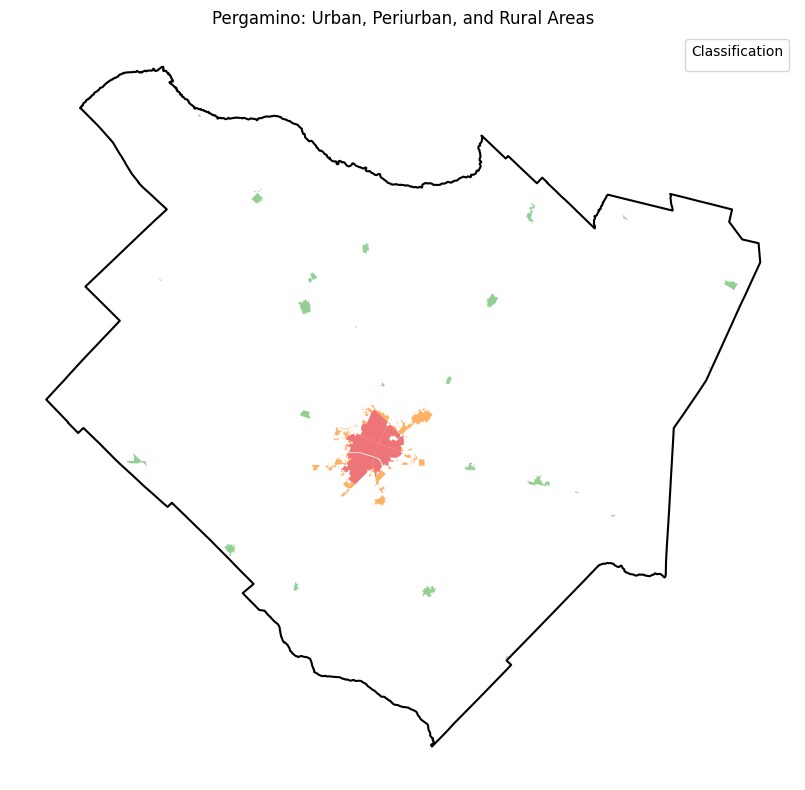

In [5]:
# | code-fold: true
# | code-summary: "Show visualization code"
fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)

pergamino.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1.5)

colors = {
    "urbana": "#e41a1c",
    "periurbana": "#ff7f00",
    "urbano en ruralidad": "#4daf4a",
}
for clase, color in colors.items():
    subset = urban_areas[urban_areas["clasificacion"] == clase]
    if len(subset) > 0:
        subset.plot(ax=ax, facecolor=color, edgecolor="none", alpha=0.6, label=clase)

ax.legend(title="Classification")
ax.set_title("Pergamino: Urban, Periurban, and Rural Areas")
ax.axis("off")
plt.tight_layout()
plt.show()

## Climate Projections: How Hot Will It Get?

We begin with historical climate data and projections because the policy conversation requires context. Telling a mayor "it's hot" is not actionable—they already know. Showing them that their city experienced an average of 39 extreme heat days per year from 1950-2014, and that this will increase to 48 by 2050, establishes a baseline and quantifies the change. This framing—where we were, where we are going—transforms abstract climate risk into a concrete trajectory that decision-makers can act on. The local analysis that follows (LST, exposure, vulnerability) identifies where within the city to focus that action.

We query CMIP6 climate projections from the Copernicus Climate Data Store to understand how extreme heat days will change over the coming decades. We use the variable "days with maximum temperature above 35°C" as our indicator of extreme heat.

::: {.callout-note}
## Understanding SSP Scenarios

The Shared Socioeconomic Pathways (SSPs) represent different possible futures based on societal choices about emissions, development, and climate policy:

- **SSP1-2.6 (Low emissions)**: Aggressive emissions reductions, limiting warming to ~1.8°C by 2100
- **SSP2-4.5 (Intermediate)**: Moderate mitigation efforts, \~2.7°C warming by 2100
- **SSP5-8.5 (High emissions)**: Continued fossil fuel dependence, ~4.4°C warming by 2100

We analyze all three scenarios because we cannot predict which path society will take. Robust planning means preparing for multiple futures.
:::

::: {.callout-tip}
## Why CDS and this variable?

The Copernicus Climate Data Store provides free, authoritative access to CMIP6 projections via API. The IPCC Atlas pre-processes common indicators like "days above 35°C" which saves significant computation. The 35°C threshold comes from the World Resources Institute's Cool Cities Lab indicators—it represents a human health threshold where heat stress becomes dangerous for sustained periods. This variable is actionable (you can set emergency protocols around it) and comparable across contexts.
:::

::: {.callout-note}
## Future: Pre-Aggregated Data on Source Cooperative

The CDS API workflow below requires registration, API key setup, and non-trivial download times. We are working on pre-aggregating common heat indicators (days >35°C, days >40°C, heat wave frequency) by administrative unit and publishing them on Source Cooperative. When available, the entire section below will reduce to a single GeoParquet query. Check the [Source Cooperative](https://source.coop/) for updates.
:::

In [6]:
import cdsapi

# Define experiments to download
experiments = {
    "historical": {"experiment": "historical", "period": None},
    "ssp1_2_6": {"experiment": "ssp1_2_6", "period": "2015-2100"},
    "ssp2_4_5": {"experiment": "ssp2_4_5", "period": "2015-2100"},
    "ssp5_8_5": {"experiment": "ssp5_8_5", "period": "2015-2100"},
}

c = cdsapi.Client()

# Get center point for Pergamino
center_lon = (bbox_wgs84[0] + bbox_wgs84[2]) / 2
center_lat = (bbox_wgs84[1] + bbox_wgs84[3]) / 2
print(f"Query center: {center_lat:.4f}, {center_lon:.4f}")

# Dictionary to store processed data
all_data = {}

for exp_name, exp_config in experiments.items():
    zip_file = f"ipcc_atlas_{exp_name}.zip"
    extract_dir = f"ipcc_{exp_name}_data"

    # Download if not exists
    if not Path(zip_file).exists():
        print(f"Downloading {exp_name}...")
        try:
            request = {
                "origin": "cmip6",
                "experiment": exp_config["experiment"],
                "domain": "global",
                "variable": "monthly_count_of_days_with_maximum_temperature_above_35_c",
            }
            if exp_config["period"]:
                request["period"] = exp_config["period"]

            c.retrieve("projections-climate-atlas", request, zip_file)
        except Exception as e:
            print(f"Error downloading {exp_name}: {e}")
            continue
    else:
        print(f"Using cached {exp_name}")

    # Extract and process
    try:
        if not Path(extract_dir).exists():
            with zipfile.ZipFile(zip_file, "r") as zip_ref:
                zip_ref.extractall(extract_dir)

        nc_files = [f for f in os.listdir(extract_dir) if f.endswith(".nc")]
        actual_nc_file = os.path.join(extract_dir, nc_files[0])

        # Load and subset to Pergamino location
        ds = xr.open_dataset(actual_nc_file)
        ds_subset = ds.sel(lon=center_lon, lat=center_lat, method="nearest")

        # Average across ensemble members (different climate models)
        tx35_mean = ds_subset["tx35"].mean(dim="member")

        # Convert to annual totals
        df = tx35_mean.to_dataframe().reset_index()
        df["year"] = df["time"].dt.year
        annual_days = df.groupby("year")["tx35"].sum().reset_index()
        annual_days.columns = ["year", "days_over_35C"]

        all_data[exp_name] = annual_days
        print(
            f"  {exp_name}: {len(annual_days)} years, mean={annual_days['days_over_35C'].mean():.1f} days/year"
        )

        ds.close()

    except Exception as e:
        print(f"Error processing {exp_name}: {e}")
        continue

Query center: -33.8583, -60.5408
Using cached historical
  historical: 165 years, mean=26.5 days/year
Using cached ssp1_2_6
  ssp1_2_6: 86 years, mean=49.8 days/year
Using cached ssp2_4_5
  ssp2_4_5: 86 years, mean=53.1 days/year
Using cached ssp5_8_5
  ssp5_8_5: 86 years, mean=62.2 days/year


In [7]:
# Calculate key statistics
historical_1950 = all_data["historical"][all_data["historical"]["year"] >= 1950].copy()
hist_baseline = historical_1950["days_over_35C"].mean()

print("=" * 60)
print("HISTORICAL BASELINE (1950-2014)")
print("=" * 60)
print(f"Mean days >35°C per year: {hist_baseline:.1f}")
print(f"Standard deviation: {historical_1950['days_over_35C'].std():.1f}")
print(
    f"Range: {historical_1950['days_over_35C'].min():.0f} - {historical_1950['days_over_35C'].max():.0f}"
)
print()

# Calculate projections for key time periods
print("PROJECTIONS BY TIME PERIOD")
print("-" * 60)

time_periods = [
    ("2020-2050", 2020, 2050),
    ("2050-2070", 2050, 2070),
    ("2070-2100", 2070, 2100),
]

labels = {
    "ssp1_2_6": "SSP1-2.6 (Low)",
    "ssp2_4_5": "SSP2-4.5 (Intermediate)",
    "ssp5_8_5": "SSP5-8.5 (High)",
}

for period_name, start, end in time_periods:
    print(f"\n{period_name}:")
    for scenario in ["ssp1_2_6", "ssp2_4_5", "ssp5_8_5"]:
        data = all_data[scenario]
        period_data = data[(data["year"] >= start) & (data["year"] <= end)]
        period_mean = period_data["days_over_35C"].mean()
        change = period_mean - hist_baseline
        pct_change = (change / hist_baseline) * 100
        print(
            f"  {labels[scenario]}: {period_mean:.1f} days/year (+{change:.1f}, {pct_change:+.0f}%)"
        )

HISTORICAL BASELINE (1950-2014)
Mean days >35°C per year: 38.7
Standard deviation: 2.6
Range: 33 - 44

PROJECTIONS BY TIME PERIOD
------------------------------------------------------------

2020-2050:
  SSP1-2.6 (Low): 48.4 days/year (+9.7, +25%)
  SSP2-4.5 (Intermediate): 48.0 days/year (+9.3, +24%)
  SSP5-8.5 (High): 49.3 days/year (+10.7, +28%)

2050-2070:
  SSP1-2.6 (Low): 51.6 days/year (+12.9, +33%)
  SSP2-4.5 (Intermediate): 54.3 days/year (+15.6, +40%)
  SSP5-8.5 (High): 61.3 days/year (+22.7, +59%)

2070-2100:
  SSP1-2.6 (Low): 51.0 days/year (+12.3, +32%)
  SSP2-4.5 (Intermediate): 58.8 days/year (+20.1, +52%)
  SSP5-8.5 (High): 78.4 days/year (+39.8, +103%)


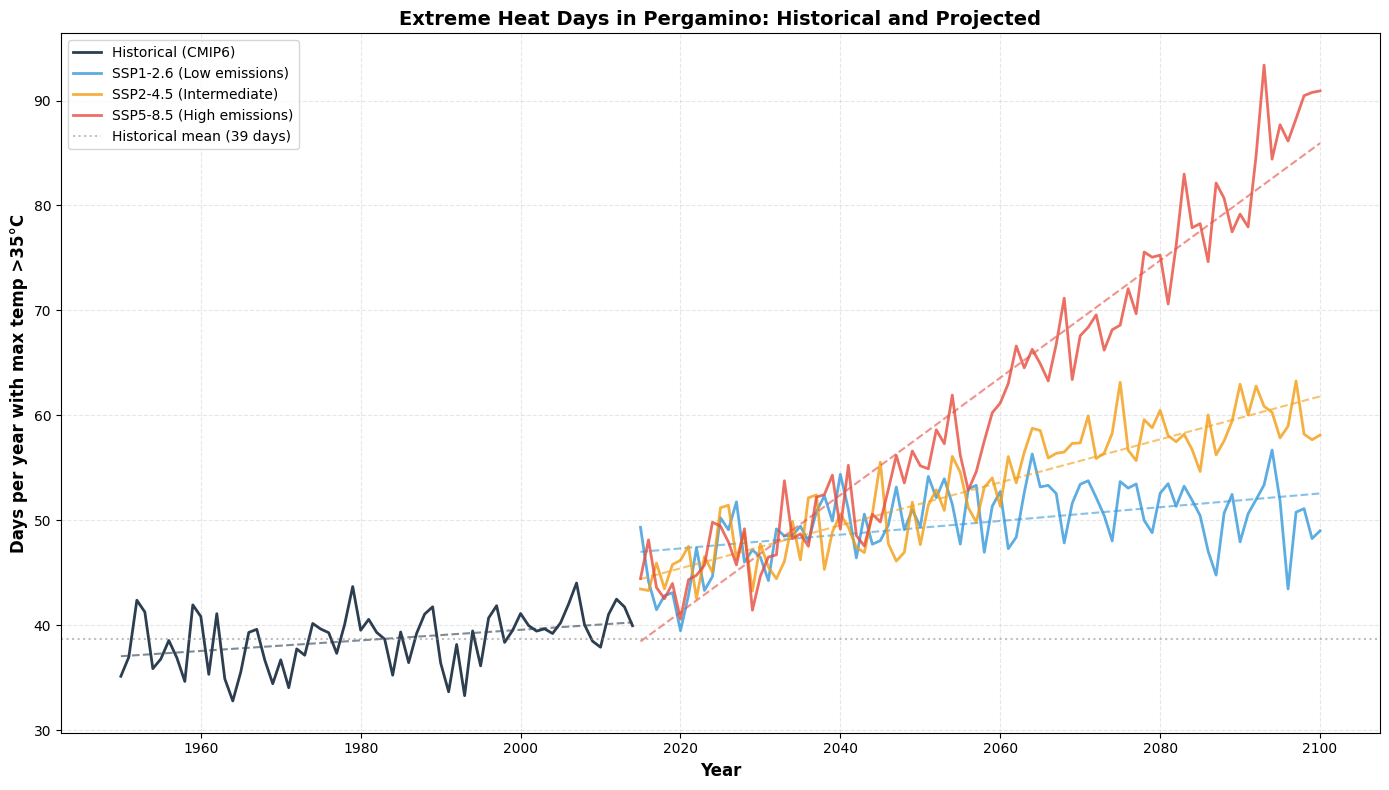

In [8]:
# | code-fold: true
# | code-summary: "Show visualization code"
from scipy import stats

fig, ax = plt.subplots(figsize=(14, 8))

colors = {
    "historical": "#2c3e50",
    "ssp1_2_6": "#3498db",
    "ssp2_4_5": "#f39c12",
    "ssp5_8_5": "#e74c3c",
}

labels_full = {
    "historical": "Historical (CMIP6)",
    "ssp1_2_6": "SSP1-2.6 (Low emissions)",
    "ssp2_4_5": "SSP2-4.5 (Intermediate)",
    "ssp5_8_5": "SSP5-8.5 (High emissions)",
}

# Plot historical
ax.plot(
    historical_1950["year"],
    historical_1950["days_over_35C"],
    linewidth=2,
    color=colors["historical"],
    label=labels_full["historical"],
)

# Add historical trend line
z_hist = np.polyfit(historical_1950["year"], historical_1950["days_over_35C"], 1)
p_hist = np.poly1d(z_hist)
ax.plot(
    historical_1950["year"],
    p_hist(historical_1950["year"]),
    "--",
    linewidth=1.5,
    color=colors["historical"],
    alpha=0.6,
)

# Plot projections
for scenario in ["ssp1_2_6", "ssp2_4_5", "ssp5_8_5"]:
    data = all_data[scenario]
    ax.plot(
        data["year"],
        data["days_over_35C"],
        linewidth=2,
        color=colors[scenario],
        label=labels_full[scenario],
        alpha=0.8,
    )

    # Add trend line
    z = np.polyfit(data["year"], data["days_over_35C"], 1)
    p = np.poly1d(z)
    ax.plot(
        data["year"],
        p(data["year"]),
        "--",
        linewidth=1.5,
        color=colors[scenario],
        alpha=0.6,
    )

ax.axhline(
    y=hist_baseline,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"Historical mean ({hist_baseline:.0f} days)",
)
ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_ylabel("Days per year with max temp >35°C", fontsize=12, fontweight="bold")
ax.set_title(
    "Extreme Heat Days in Pergamino: Historical and Projected",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

The projections show that under current trajectories (SSP2-4.5), Pergamino can expect:

- **By 2050**: \~48 days/year >35°C (+24% from baseline)
- **By 2070**: \~54 days/year (+40%)
- **By 2100**: \~59 days/year (+52%)

Even under aggressive emissions reductions (SSP1-2.6), the city will experience increased heat stress. This is why we need to plan for multiple scenarios rather than a single "most likely" future.

## Current Heat Patterns: Where Is It Hottest Now?

The climate projections tell us heat is increasing and by how much. Now we need to know where within the city to focus adaptation efforts. This section zooms from coarse climate model resolution (~100km) to fine satellite resolution (30m) to identify specific hotspots.

We calculate Land Surface Temperature (LST) from Landsat satellite imagery, computing the maximum LST over the past 5 years to identify persistently hot areas.

::: {.callout-important}
## LST vs. Air Temperature

Land Surface Temperature measures how hot the ground surface is, not air temperature. LST can exceed air temperature by 20°C or more on hot days. We use LST as a **relative indicator** to identify which areas are hotter than others, not to predict human heat exposure directly.
:::

::: {.callout-tip}
## Why Landsat LST?

Heat is an urgent issue, and for many cities, complexity of calculation means they will never have data to act on. More sophisticated measures like wet-bulb globe temperature or Universal Thermal Comfort Index require more data and computation.

We use Landsat specifically because it provides 30m resolution thermal imagery—fine enough to distinguish individual blocks and parks. MODIS thermal data is coarser (~1km), which obscures the neighborhood-level patterns we need for targeting interventions. Landsat Collection 2 Level-2 data is freely available through Microsoft Planetary Computer with no authentication required, making this workflow reproducible anywhere.

LST is imperfect but **good enough to make meaningful decisions**. We are not waiting for perfect data—we are working with what we have to act now.
:::

In [9]:
import planetary_computer
import pystac_client
from odc.stac import stac_load, configure_rio
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# Connect to Planetary Computer
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Set up Dask cluster for parallel processing
cluster = LocalCluster(
    processes=True,
    n_workers=4,
    threads_per_worker=2,
    memory_limit="4GB",
    dashboard_address=":0",
)
dask_client = Client(cluster)
configure_rio(cloud_defaults=True, client=dask_client)

# Query Landsat for last 5 years
datetime = "2020-01-01/2025-01-01"
cloudy_less_than = 20

query = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox_wgs84,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": cloudy_less_than}},
)

items = list(query.items())
print(f"Found {len(items)} Landsat scenes")

Found 488 Landsat scenes


In [10]:
# Check for cached LST file
lst_tif_path = Path("LST_max_pergamino.tif")

if lst_tif_path.exists():
    print(f"Loading cached LST from {lst_tif_path}")
    LST_max = rio.open_rasterio(lst_tif_path)
    if len(LST_max.dims) > 2:
        LST_max = LST_max.squeeze()
else:
    print("Computing LST from Landsat imagery...")

    # Load thermal band and QA
    crs = "epsg:3857"
    yy = stac_load(
        items,
        bands=("lwir11", "qa_pixel"),
        crs=crs,
        resolution=30,
        chunks={"time": 10},
        groupby="landsat:scene_id",
        bbox=bbox_wgs84,
    )

    # Cloud mask function
    def create_cloud_mask(qa_band):
        """Mask clouds and cloud shadows (bits 3 and 4)"""
        cloud_mask = (qa_band & 0b11000) == 0
        return cloud_mask

    # Apply cloud mask
    yy_masked = yy.where(create_cloud_mask(yy.qa_pixel))

    # Convert to LST in Celsius
    LST_kelvin = yy_masked["lwir11"] * 0.00341802 + 149.0
    LST_celsius = LST_kelvin - 273.15

    # Calculate maximum LST per pixel
    LST_max_lazy = LST_celsius.max(dim="time")

    print("Computing (this may take a few minutes)...")
    with ProgressBar():
        LST_max = LST_max_lazy.compute()

    # Save to file
    LST_max.rio.to_raster(lst_tif_path)
    print(f"Saved to {lst_tif_path}")

# Basic stats
print("\nLST Statistics:")
print(f"  Min: {float(LST_max.min()):.1f}°C")
print(f"  Max: {float(LST_max.max()):.1f}°C")
print(f"  Mean: {float(LST_max.mean()):.1f}°C")

Loading cached LST from LST_max_pergamino.tif

LST Statistics:
  Min: 33.7°C
  Max: 65.4°C
  Mean: 52.9°C


### Hotspot Identification by Urban Classification

::: {.callout-note}
## Why Per-Classification Thresholds?

If we calculated a single P75 threshold across all of Pergamino, the hotspots would be dominated by agricultural fields and industrial zones—areas that are hot but largely unpopulated. Our interest is not "where is it hot" but "where is it hot **and there are people**."

By calculating P75 within each urban classification (urban, periurban, rural settlements), we identify relative hotspots within each type of area. A hotspot in the urban core might be 38°C while a hotspot in periurban areas is 42°C. Both are the hottest areas within their context—and both need attention.

This is a heuristic, not a perfect measure. Local knowledge should always supplement quantitative analysis.
:::

In [11]:
# Reproject urban areas to match LST CRS
urban_areas_lst_crs = urban_areas.to_crs(LST_max.rio.crs)

# Calculate P75 threshold for EACH urban classification
thresholds = {}
hotspot_masks = {}

for urban_class in urban_areas_lst_crs["clasificacion"].unique():
    class_gdf = urban_areas_lst_crs[urban_areas_lst_crs["clasificacion"] == urban_class]

    # Get all LST values within this classification
    lst_values = []
    for geom in class_gdf.geometry:
        stats = zonal_stats(
            [geom],
            LST_max.squeeze().values,
            affine=LST_max.rio.transform(),
            stats=["mean"],
            nodata=np.nan,
            raster_out=True,
        )
        if stats[0]["mini_raster_array"] is not None:
            valid_vals = stats[0]["mini_raster_array"].compressed()
            lst_values.extend(valid_vals)

    # Calculate P75 threshold for this classification
    threshold = np.percentile(lst_values, 75) if len(lst_values) > 0 else np.nan
    thresholds[urban_class] = threshold

    # Create hotspot mask (integer 0/1)
    hotspot_masks[urban_class] = (LST_max.squeeze().values >= threshold).astype(int)

    print(
        f"{urban_class}: P75 threshold = {threshold:.1f}°C, "
        f"mean LST = {np.mean(lst_values):.1f}°C"
    )

urbana: P75 threshold = 47.7°C, mean LST = 46.1°C
periurbana: P75 threshold = 51.4°C, mean LST = 49.3°C
urbano en ruralidad: P75 threshold = 49.4°C, mean LST = 47.9°C


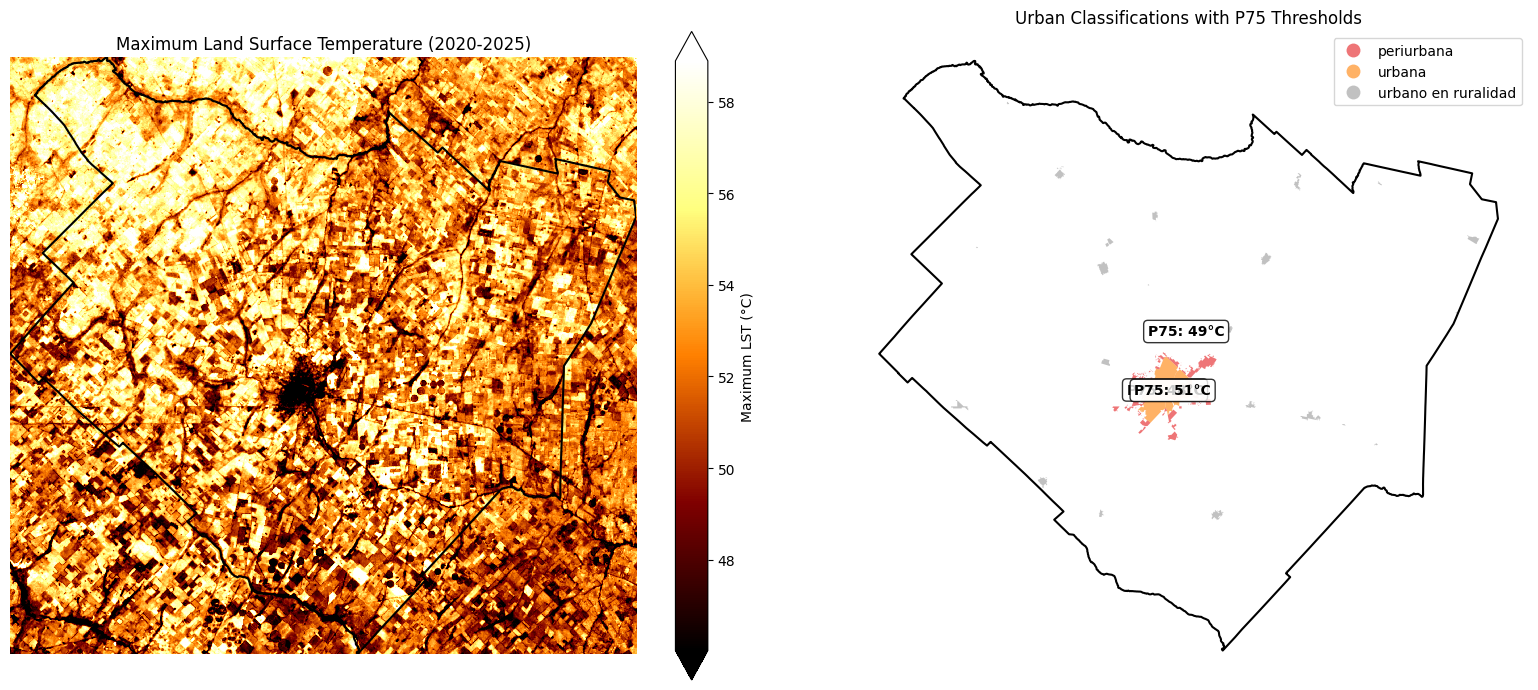

In [12]:
# | code-fold: true
# | code-summary: "Show visualization code"
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: LST values
LST_max.plot.imshow(
    ax=axes[0],
    cmap="afmhot",
    cbar_kwargs={"label": "Maximum LST (°C)"},
    robust=True,
)
pergamino.to_crs(LST_max.rio.crs).plot(
    ax=axes[0], facecolor="none", edgecolor="black", linewidth=1.5
)
axes[0].set_title("Maximum Land Surface Temperature (2020-2025)")
axes[0].axis("off")

# Right: Urban classifications with thresholds
urban_areas_lst_crs.plot(
    ax=axes[1],
    column="clasificacion",
    cmap="Set1",
    legend=True,
    alpha=0.6,
)
pergamino.to_crs(LST_max.rio.crs).plot(
    ax=axes[1], facecolor="none", edgecolor="black", linewidth=1.5
)

# Add threshold annotations
for clase, thresh in thresholds.items():
    centroid = (
        urban_areas_lst_crs[urban_areas_lst_crs["clasificacion"] == clase]
        .union_all()
        .centroid
    )
    axes[1].annotate(
        f"P75: {thresh:.0f}°C",
        xy=(centroid.x, centroid.y),
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

axes[1].set_title("Urban Classifications with P75 Thresholds")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Exposure: Who Lives in Hot Areas?

::: {.callout-note}
## Measuring Population Exposure

We use multiple data sources to measure population exposure because no single source is perfect. See Chapter 3 for a detailed discussion of each source's methodology and limitations.

- **GHSL (Global Human Settlement Layer)**: Gridded population at 100m resolution. Available globally but model-derived, not counted. Uses satellite imagery and statistical modeling to disaggregate national population totals.
- **WorldPop**: Similar methodology to GHSL with different modeling assumptions. Useful for triangulation but we omit it here since it provides comparable estimates.
- **Census data**: Authoritative counts (in theory), but often inaccurate and at coarse resolution. The Argentine census is known to undercount by several million people. Resolution is limited to census tract boundaries.
- **Building footprints**: Structural exposure proxy. More buildings ≈ more people. Does not directly measure population but indicates where people could live.

For a robust analysis, triangulate multiple sources and report ranges rather than single numbers. "Between 8,000 and 12,000 people are exposed" is more honest than false precision. When sources diverge significantly, investigate why—it often reveals something important about the area.
:::

### GHSL Population

In [13]:
# GHSL Population (2025, 100m)
ghsl_url = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/GHS_POP_E2025_GLOBE_R2023A_54009_100/V1-0/tiles/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R14_C13.zip"

# Virtual path to read from remote ZIP
vsi_path = (
    f"/vsizip/vsicurl/{ghsl_url}/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R14_C13.tif"
)

ghsl = rio.open_rasterio(vsi_path, chunks={"x": 2048, "y": 2048})

# Clip to study area
aoi_ghsl_crs = urban_areas.to_crs("ESRI:54009")
ghsl_clipped = ghsl.rio.clip(aoi_ghsl_crs.geometry.values, from_disk=True)
ghsl_clipped = ghsl_clipped.rio.reproject(USE_CRS)
ghsl_masked = ghsl_clipped.where(ghsl_clipped > 0)

total_pop_ghsl = float(ghsl_masked.sum())
print(f"GHSL estimated population: {total_pop_ghsl:,.0f}")

GHSL estimated population: 163,397


### Census Population

In [16]:
# Census population from Source Cooperative
con = duckdb.connect()
for cmd in [
    "INSTALL spatial",
    "LOAD spatial",
    "INSTALL httpfs",
    "LOAD httpfs",
    "SET s3_region='us-east-1'",
    "SET s3_endpoint='data.source.coop'",
    "SET s3_use_ssl=true",
    "SET s3_url_style='path'",
]:
    con.execute(cmd)

bounds = urban_areas.to_crs(WGS84_CRS).total_bounds

# Query census tracts with population and deprivation data
query = f"""
WITH privacion_data AS (
    SELECT
        id_geo,
        SUM(CASE WHEN valor_categoria IN ('2', '3', '4') THEN conteo ELSE 0 END) AS hogares_con_privacion,
        SUM(conteo) AS total_hogares
    FROM 'https://data.source.coop/nlebovits/censo-argentino/2022/census-data.parquet'
    WHERE codigo_variable = 'HOGAR_IPMH'
    GROUP BY id_geo
    HAVING total_hogares > 0
)
SELECT
    g.COD_2022,
    g.POB_TOT_P,
    ST_AsWKB(g.geometry) as geometry,
    COALESCE(p.hogares_con_privacion, 0) as hogares_con_privacion,
    COALESCE(p.total_hogares, 0) as total_hogares,
    CASE WHEN p.total_hogares > 0
         THEN ROUND((p.hogares_con_privacion * 100.0) / p.total_hogares, 2)
         ELSE 0 END AS pct_privacion
FROM 'https://data.source.coop/nlebovits/censo-argentino/2022/radios.parquet' g
LEFT JOIN privacion_data p ON g.COD_2022 = p.id_geo
WHERE g.bbox.xmax >= {bounds[0]}
  AND g.bbox.xmin <= {bounds[2]}
  AND g.bbox.ymax >= {bounds[1]}
  AND g.bbox.ymin <= {bounds[3]}
"""

df = con.execute(query).fetchdf()
df["geometry"] = gpd.GeoSeries.from_wkb(df["geometry"].apply(bytes))
census_tracts = gpd.GeoDataFrame(df, geometry="geometry", crs=WGS84_CRS)
census_tracts = census_tracts.to_crs(USE_CRS)
census_tracts = gpd.clip(census_tracts, urban_areas.union_all())

total_pop_census = census_tracts["POB_TOT_P"].sum()
print(f"Census population (urban areas): {total_pop_census:,}")
print(f"Census tracts: {len(census_tracts)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Census population (urban areas): 114,472
Census tracts: 193


### Building Footprints

In [17]:
# Building footprints from Source Cooperative
buildings_file = "buildings_pergamino.parquet"

if not Path(buildings_file).exists():
    query = f"""
    COPY (
        SELECT *
        FROM 's3://vida/google-microsoft-open-buildings/geoparquet/by_country/country_iso=ARG/ARG.parquet'
        WHERE bbox.xmax >= {bounds[0]} AND bbox.xmin <= {bounds[2]} AND
              bbox.ymax >= {bounds[1]} AND bbox.ymin <= {bounds[3]}
    ) TO '{buildings_file}' (FORMAT PARQUET);
    """
    con.execute(query)

buildings_df = pd.read_parquet(buildings_file)
buildings_df["geometry"] = gpd.GeoSeries.from_wkb(buildings_df["geometry"].apply(bytes))
buildings = gpd.GeoDataFrame(buildings_df, geometry="geometry", crs=WGS84_CRS)
buildings = buildings.to_crs(USE_CRS)
buildings = gpd.clip(buildings, urban_areas.union_all())

total_buildings = len(buildings)
print(f"Total buildings: {total_buildings:,}")

Total buildings: 103,371


In [18]:
# Exposure summary - comparing sources
pop_estimates = [total_pop_ghsl, total_pop_census]
pop_min = min(pop_estimates)
pop_max = max(pop_estimates)

print("=" * 60)
print("EXPOSURE METRICS COMPARISON")
print("=" * 60)
print(f"GHSL population estimate:  {total_pop_ghsl:>10,.0f}")
print(f"Census population:         {total_pop_census:>10,}")
print(f"Buildings:                 {total_buildings:>10,}")
print()
print(f"Population range:          {pop_min:,.0f} - {pop_max:,.0f}")
print(
    f"GHSL vs Census difference: {((total_pop_ghsl - total_pop_census) / total_pop_census) * 100:+.1f}%"
)
print(f"People per building:       {total_pop_census / total_buildings:.1f} (census)")
print("=" * 60)

EXPOSURE METRICS COMPARISON
GHSL population estimate:     163,397
Census population:            114,472
Buildings:                    103,371

Population range:          114,472 - 163,397
GHSL vs Census difference: +42.7%
People per building:       1.1 (census)


### Understanding Source Divergence

The difference between GHSL and census estimates reveals important characteristics of each source:

**Why GHSL and census differ:**

- **Temporal mismatch**: GHSL 2025 projections are modeled forward from earlier data, while census data captures a specific moment (2022 for Argentina).
- **Spatial distribution**: GHSL disaggregates population to a 100m grid using building detection, which can over- or under-estimate density in specific areas.
- **Undercounting**: Census data systematically undercounts certain populations (informal settlements, transient workers, people who distrust government surveys).

**What buildings tell us:**

Building footprints provide a structural check on population estimates. The ratio of people per building (shown above) helps validate whether population estimates are plausible. A ratio of 2-4 people per building is typical for areas with a mix of single-family homes and small apartment buildings.

**Practical implications:**

For policy purposes, we use the census-based estimate for calculating exposure rates (it is the official figure municipalities work with) but report the range to acknowledge uncertainty. When GHSL and census diverge by more than 20%, it warrants investigation—the divergence itself is informative.

### Population Exposure by Urban Classification

Now we calculate population in hotspots using the per-classification P75 thresholds. We resample population to 30m to match LST resolution, correcting for the pixel size change.

In [19]:
# Resample GHSL to 30m to match LST resolution
# Divide by ~11 because 100m pixels become ~11 30m pixels
ghsl_30m = (
    ghsl_clipped.rio.reproject_match(
        LST_max,
        resampling=rasterio.enums.Resampling.bilinear,
    )
    / 11.1111
)

ghsl_30m = ghsl_30m.where(ghsl_30m > 0, 0)

# Calculate exposure for each urban classification
exposure_results = []

for urban_class in urban_areas_lst_crs["clasificacion"].unique():
    class_gdf = urban_areas_lst_crs[urban_areas_lst_crs["clasificacion"] == urban_class]
    hotspot_mask = hotspot_masks[urban_class]

    # Total population in this classification
    total_pop = sum(
        [
            s["sum"]
            for s in zonal_stats(
                class_gdf.geometry,
                ghsl_30m.squeeze().values,
                affine=ghsl_30m.rio.transform(),
                stats=["sum"],
                nodata=np.nan,
            )
            if s["sum"] is not None
        ]
    )

    # Population in hotspots (multiply by 0/1 mask)
    pop_exposed_array = ghsl_30m.squeeze().values * hotspot_mask
    pop_exposed = sum(
        [
            s["sum"]
            for s in zonal_stats(
                class_gdf.geometry,
                pop_exposed_array,
                affine=ghsl_30m.rio.transform(),
                stats=["sum"],
                nodata=np.nan,
            )
            if s["sum"] is not None
        ]
    )

    exposure_results.append(
        {
            "classification": urban_class,
            "threshold_C": thresholds[urban_class],
            "total_pop": int(total_pop),
            "pop_exposed": int(pop_exposed),
            "pct_exposed": round(pop_exposed / total_pop * 100, 1)
            if total_pop > 0
            else 0,
        }
    )

exposure_df = pd.DataFrame(exposure_results)
print("\nEXPOSURE BY URBAN CLASSIFICATION (GHSL)")
print(exposure_df.to_string(index=False))


EXPOSURE BY URBAN CLASSIFICATION (GHSL)
     classification  threshold_C  total_pop  pop_exposed  pct_exposed
             urbana    47.745636     144104        11596          8.0
         periurbana    51.423431       5056          521         10.3
urbano en ruralidad    49.410217      14209         1726         12.2


## Vulnerability: Who Is Most at Risk?

Vulnerability measures who is most susceptible to harm from a hazard. Unlike exposure (which asks "who is there?"), vulnerability asks "who lacks the capacity to cope?" See Chapter 3 for a detailed discussion of vulnerability concepts and measurement approaches.

::: {.callout-note}
## Measuring Vulnerability: A Worked Example

There is no perfect global vulnerability indicator. Vulnerability is context-dependent, shaped by local economic conditions, social structures, housing stock, and institutional capacity. What works in Buenos Aires may not apply in Lagos or Mumbai.

We use **IPMH (Índice de Privación Material de los Hogares)** from the Argentine census as our worked example. We chose it because:

- It is available at census tract level for all of Argentina
- It is an official statistic that municipal planners recognize and trust
- Material deprivation generally correlates with climate vulnerability

<!-- TODO: Research and document what IPMH specifically measures (components, thresholds, methodology). See INDEC documentation. -->

For other contexts, consider these alternatives:

- **Relative Wealth Index** (Meta/Facebook): Global, gridded at ~2km resolution. Derived from satellite imagery and connectivity data. Useful where census data is unavailable.
- **Informal settlement boundaries**: Where mapped, informal settlements concentrate multiple vulnerability factors. Available from local governments or NGOs.
- **Housing quality indicators**: From local surveys or building permit data. Directly measures structural vulnerability.
- **Age demographics**: Elderly populations face elevated heat risk. Children are also vulnerable. Available from census data where age breakdowns exist.

These are all proxies for underlying vulnerability. None captures the full picture.
:::

::: {.callout-important}
## Local Knowledge Is Essential

Quantitative vulnerability indicators identify patterns but miss critical details. They cannot tell you:

- Which buildings have functioning air conditioning vs. broken units
- Where elderly residents live alone without family support
- Which neighborhoods have active mutual aid networks
- Where informal workers cannot leave their posts during heat emergencies

**Always supplement quantitative analysis with local knowledge.** Municipal officials, community health workers, and neighborhood organizations know things that no dataset captures. The goal of this analysis is to focus attention and resources—not to replace local expertise.
:::

In [20]:
# Rasterize deprivation data to match GHSL grid
forma_referencia = ghsl_clipped.shape[1:]
transformacion_referencia = ghsl_clipped.rio.transform()

# Population by census tract
census_tracts_use_crs = census_tracts.to_crs(USE_CRS)

raster_pob_censo = rasterize(
    [
        (geom, valor)
        for geom, valor in zip(
            census_tracts_use_crs.geometry, census_tracts_use_crs["POB_TOT_P"]
        )
    ],
    out_shape=forma_referencia,
    transform=transformacion_referencia,
    fill=0,
    dtype=np.float32,
    all_touched=True,
)

# Deprivation proportion by census tract
raster_privacion = rasterize(
    [
        (geom, valor / 100)
        for geom, valor in zip(
            census_tracts_use_crs.geometry, census_tracts_use_crs["pct_privacion"]
        )
    ],
    out_shape=forma_referencia,
    transform=transformacion_referencia,
    fill=0,
    dtype=np.float32,
    all_touched=True,
)

# Calculate GHSL totals per census tract for redistribution weights
raster_ghsl = ghsl_clipped.values[0]

# Create tract ID raster
raster_tract_ids = rasterize(
    [(geom, i + 1) for i, geom in enumerate(census_tracts_use_crs.geometry)],
    out_shape=forma_referencia,
    transform=transformacion_referencia,
    fill=0,
    all_touched=True,
    dtype=np.int32,
)

# Calculate GHSL sum per tract
ghsl_per_tract = []
for i in range(len(census_tracts_use_crs)):
    tract_mask = raster_tract_ids == (i + 1)
    valid_mask = tract_mask & (raster_ghsl > 0) & (raster_ghsl != -200)
    total = np.sum(raster_ghsl[valid_mask]) if np.any(valid_mask) else 0
    ghsl_per_tract.append(total)

# Rasterize GHSL totals per tract
raster_ghsl_per_tract = rasterize(
    [
        (geom, valor)
        for geom, valor in zip(census_tracts_use_crs.geometry, ghsl_per_tract)
    ],
    out_shape=forma_referencia,
    transform=transformacion_referencia,
    fill=0,
    dtype=np.float32,
    all_touched=True,
)

# Dasymetric redistribution: use GHSL as weights to redistribute census population
mascara = (raster_ghsl > 0) & (raster_ghsl != -200) & (raster_ghsl_per_tract > 0.1)
ghsl_fraccional = np.full_like(raster_ghsl, 0, dtype=np.float64)
ghsl_fraccional[mascara] = raster_ghsl[mascara] / raster_ghsl_per_tract[mascara]

mascara2 = (ghsl_fraccional > 0) & (raster_pob_censo > 0)
pob_redistribuida = np.full_like(raster_ghsl, 0, dtype=np.float64)
pob_redistribuida[mascara2] = ghsl_fraccional[mascara2] * raster_pob_censo[mascara2]

# Create DataArray
pob_redistribuida_da = xr.DataArray(
    pob_redistribuida,
    coords={"y": ghsl_clipped.y, "x": ghsl_clipped.x},
    dims=["y", "x"],
)
pob_redistribuida_da = pob_redistribuida_da.rio.write_crs(USE_CRS)
pob_redistribuida_enmascarada = pob_redistribuida_da.where(pob_redistribuida_da > 0)

# Calculate population in deprivation
mascara_pob_privacion = (pob_redistribuida > 0) & (raster_privacion > 0)
pob_privacion = np.full_like(pob_redistribuida, 0, dtype=np.float64)
pob_privacion[mascara_pob_privacion] = (
    pob_redistribuida[mascara_pob_privacion] * raster_privacion[mascara_pob_privacion]
)

pob_privacion_da = xr.DataArray(
    pob_privacion,
    coords={"y": ghsl_clipped.y, "x": ghsl_clipped.x},
    dims=["y", "x"],
)
pob_privacion_da = pob_privacion_da.rio.write_crs(USE_CRS)
pob_privacion_enmascarada = pob_privacion_da.where(pob_privacion_da > 0)

total_redistribuido = pob_redistribuida[pob_redistribuida > 0].sum()
total_pob_privacion = pob_privacion[pob_privacion > 0].sum()

print(f"Census population: {total_pop_census:,.0f}")
print(f"Redistributed population: {total_redistribuido:,.0f}")
print(f"Conservation: {(total_redistribuido / total_pop_census) * 100:.1f}%")
print(f"Population in deprivation: {total_pob_privacion:,.0f}")
print(f"Deprivation rate: {(total_pob_privacion / total_redistribuido) * 100:.1f}%")

Census population: 114,472
Redistributed population: 114,171
Conservation: 99.7%
Population in deprivation: 36,199
Deprivation rate: 31.7%


### IPMH as a Vulnerability Proxy

<!-- TODO: Research and document what IPMH specifically measures and how it relates to heat vulnerability. Add section explaining:
- What IPMH components are (from INDEC methodology)
- How these relate to heat vulnerability specifically
- What IPMH does NOT capture (age, health, social networks, occupational exposure)
-->

**General limitations of material deprivation indices:**

Any material deprivation index—including IPMH—will miss important vulnerability factors:

- **Age**: Elderly populations face elevated physiological risk from heat regardless of income.
- **Health status**: Chronic conditions increase heat risk. Deprivation indices do not capture health.
- **Social isolation**: People without family or community support are more vulnerable during emergencies.
- **Occupational exposure**: Outdoor workers face heat exposure regardless of household wealth.

**Implications for this analysis:**

The deprivation rate above provides a baseline estimate of vulnerable population. Use this figure to prioritize areas for deeper investigation, not as a definitive count of vulnerable people. Field verification and local knowledge are essential.

### Vulnerable Population Exposure

In [21]:
# Resample redistributed population to 30m
pob_30m = (
    pob_redistribuida_enmascarada.rio.reproject_match(
        LST_max,
        resampling=rasterio.enums.Resampling.nearest,
    )
    / 11.1111
)

pob_privacion_30m = (
    pob_privacion_enmascarada.rio.reproject_match(
        LST_max,
        resampling=rasterio.enums.Resampling.nearest,
    )
    / 11.1111
)

# Calculate vulnerability exposure for each classification
vuln_results = []

for urban_class in urban_areas_lst_crs["clasificacion"].unique():
    class_gdf = urban_areas_lst_crs[urban_areas_lst_crs["clasificacion"] == urban_class]
    hotspot_mask = hotspot_masks[urban_class]

    # Total population
    total_pop = sum(
        [
            s["sum"]
            for s in zonal_stats(
                class_gdf.geometry,
                pob_30m.squeeze().values,
                affine=pob_30m.rio.transform(),
                stats=["sum"],
                nodata=np.nan,
            )
            if s["sum"] is not None
        ]
    )

    # Total vulnerable population
    total_vuln = sum(
        [
            s["sum"]
            for s in zonal_stats(
                class_gdf.geometry,
                pob_privacion_30m.squeeze().values,
                affine=pob_privacion_30m.rio.transform(),
                stats=["sum"],
                nodata=np.nan,
            )
            if s["sum"] is not None
        ]
    )

    # Exposed population
    pop_exposed_array = pob_30m.squeeze().values * hotspot_mask
    pop_exposed = sum(
        [
            s["sum"]
            for s in zonal_stats(
                class_gdf.geometry,
                pop_exposed_array,
                affine=pob_30m.rio.transform(),
                stats=["sum"],
                nodata=np.nan,
            )
            if s["sum"] is not None
        ]
    )

    # Exposed vulnerable population
    vuln_exposed_array = pob_privacion_30m.squeeze().values * hotspot_mask
    vuln_exposed = sum(
        [
            s["sum"]
            for s in zonal_stats(
                class_gdf.geometry,
                vuln_exposed_array,
                affine=pob_privacion_30m.rio.transform(),
                stats=["sum"],
                nodata=np.nan,
            )
            if s["sum"] is not None
        ]
    )

    # Inequity ratio
    general_rate = pop_exposed / total_pop if total_pop > 0 else 0
    vuln_rate = vuln_exposed / total_vuln if total_vuln > 0 else 0
    inequity_ratio = vuln_rate / general_rate if general_rate > 0 else 0

    vuln_results.append(
        {
            "classification": urban_class,
            "total_pop": int(total_pop),
            "pop_exposed": int(pop_exposed),
            "pct_exposed": round(pop_exposed / total_pop * 100, 1)
            if total_pop > 0
            else 0,
            "vuln_exposed": int(vuln_exposed),
            "pct_vuln_exposed": round(vuln_exposed / total_vuln * 100, 1)
            if total_vuln > 0
            else 0,
            "inequity_ratio": round(inequity_ratio, 2),
        }
    )

vuln_df = pd.DataFrame(vuln_results)
print("\nEXPOSURE AND VULNERABILITY BY URBAN CLASSIFICATION")
print(vuln_df.to_string(index=False))


EXPOSURE AND VULNERABILITY BY URBAN CLASSIFICATION
     classification  total_pop  pop_exposed  pct_exposed  vuln_exposed  pct_vuln_exposed  inequity_ratio
             urbana      98866         8790          8.9          3886              12.8            1.44
         periurbana       3652          310          8.5           180              10.8            1.27
urbano en ruralidad      10676         1194         11.2           369              10.3            0.92


## Risk Summary by Neighborhood

In [22]:
barrios_lst_crs = barrios.to_crs(LST_max.rio.crs)

# Use the last hotspot mask (we'll need to be smarter about this)
# For neighborhoods, use the mask corresponding to their classification
# For simplicity, combine all hotspot masks
combined_hotspot_mask = np.zeros_like(list(hotspot_masks.values())[0])
for mask in hotspot_masks.values():
    combined_hotspot_mask = np.maximum(combined_hotspot_mask, mask)

results = []

for idx, barrio in barrios_lst_crs.iterrows():
    barrio_name = barrio.get("nombre", barrio.get("name", f"Barrio_{idx}"))

    # Total population
    pop_stats = zonal_stats(
        [barrio.geometry],
        pob_30m.squeeze().values,
        affine=pob_30m.rio.transform(),
        stats=["sum"],
        nodata=np.nan,
    )
    total_pop = pop_stats[0]["sum"] or 0

    # Mean LST
    lst_stats = zonal_stats(
        [barrio.geometry],
        LST_max.squeeze().values,
        affine=LST_max.rio.transform(),
        stats=["mean"],
        nodata=np.nan,
    )
    mean_lst = lst_stats[0]["mean"] or 0

    # Population in hotspots
    pop_exposed_array = pob_30m.squeeze().values * combined_hotspot_mask
    hotspot_stats = zonal_stats(
        [barrio.geometry],
        pop_exposed_array,
        affine=pob_30m.rio.transform(),
        stats=["sum"],
        nodata=np.nan,
    )
    pop_exposed = hotspot_stats[0]["sum"] or 0

    # Vulnerable population exposed
    vuln_exposed_array = pob_privacion_30m.squeeze().values * combined_hotspot_mask
    vuln_stats = zonal_stats(
        [barrio.geometry],
        vuln_exposed_array,
        affine=pob_privacion_30m.rio.transform(),
        stats=["sum"],
        nodata=np.nan,
    )
    vuln_exposed = vuln_stats[0]["sum"] or 0

    results.append(
        {
            "barrio": barrio_name,
            "total_pop": int(total_pop),
            "mean_lst": round(mean_lst, 1),
            "pop_exposed": int(pop_exposed),
            "pct_exposed": round(pop_exposed / total_pop * 100, 1)
            if total_pop > 0
            else 0,
            "vuln_exposed": int(vuln_exposed),
        }
    )

barrio_risk = pd.DataFrame(results)
barrio_risk = barrio_risk[barrio_risk["total_pop"] > 100]
barrio_risk = barrio_risk.sort_values("pop_exposed", ascending=False)

print("TOP 10 NEIGHBORHOODS BY EXPOSED POPULATION")
print("=" * 80)
print(f"{'Neighborhood':<25} {'Pop':>8} {'Exposed':>8} {'%':>6} {'Vuln':>8} {'LST':>6}")
print("-" * 80)

for _, row in barrio_risk.head(10).iterrows():
    print(
        f"{row['barrio'][:24]:<25} "
        f"{row['total_pop']:>8,} "
        f"{row['pop_exposed']:>8,} "
        f"{row['pct_exposed']:>5.1f}% "
        f"{row['vuln_exposed']:>8,} "
        f"{row['mean_lst']:>5.1f}°"
    )

TOP 10 NEIGHBORHOODS BY EXPOSED POPULATION
Neighborhood                   Pop  Exposed      %     Vuln    LST
--------------------------------------------------------------------------------
Martín Illia                 4,837    1,404  29.0%      695  47.6°
12 de Octubre                3,116    1,302  41.8%      930  50.2°
Villa San José               6,044      953  15.8%      402  47.2°
Malvinas                     2,639      870  33.0%      222  48.0°
Kennedy                      2,144      822  38.3%      519  47.9°
Santa Inés                     777      777 100.0%      556  51.6°
Champagnat                   1,095      427  39.1%      126  51.8°
Atahualpa Yupanqui           1,518      379  25.0%       52  47.7°
Acevedo                     11,784      377   3.2%      127  45.7°
Quinta Mastrángelo             543      350  64.5%      283  50.6°


## Risk Summary

In [23]:
print("=" * 70)
print("EXTREME HEAT RISK SUMMARY: PERGAMINO")
print("=" * 70)

print("\nCLIMATE TRENDS")
print(f"  Historical baseline (1950-2014): {hist_baseline:.1f} days/year >35°C")
print("  Projected 2050 (SSP2-4.5): ~48 days/year (+24%)")
print("  Projected 2070 (SSP2-4.5): ~54 days/year (+40%)")
print("  Projected 2100 (SSP2-4.5): ~59 days/year (+52%)")

print("\nCURRENT HEAT PATTERNS")
for clase, thresh in thresholds.items():
    print(f"  {clase}: P75 threshold = {thresh:.1f}°C")

print("\nPOPULATION EXPOSURE")
total_exposed = vuln_df["pop_exposed"].sum()
total_pop_all = vuln_df["total_pop"].sum()
print(f"  Population range (GHSL/Census): {pop_min:,.0f} - {pop_max:,.0f}")
print(f"  Census population (official): {total_pop_census:,}")
print(
    f"  Population in heat hotspots: {total_exposed:,} ({total_exposed / total_pop_all * 100:.1f}%)"
)

print("\nVULNERABILITY")
total_vuln_exposed = vuln_df["vuln_exposed"].sum()
print(f"  Vulnerable population in hotspots: {total_vuln_exposed:,}")
for _, row in vuln_df.iterrows():
    if row["inequity_ratio"] > 1:
        print(f"  {row['classification']}: {row['inequity_ratio']:.2f}x inequity ratio")

print("\nPRIORITY NEIGHBORHOODS")
for _, row in barrio_risk.head(3).iterrows():
    print(
        f"  - {row['barrio']}: {row['pop_exposed']:,} exposed ({row['pct_exposed']:.0f}%)"
    )

print("=" * 70)

EXTREME HEAT RISK SUMMARY: PERGAMINO

CLIMATE TRENDS
  Historical baseline (1950-2014): 38.7 days/year >35°C
  Projected 2050 (SSP2-4.5): ~48 days/year (+24%)
  Projected 2070 (SSP2-4.5): ~54 days/year (+40%)
  Projected 2100 (SSP2-4.5): ~59 days/year (+52%)

CURRENT HEAT PATTERNS
  urbana: P75 threshold = 47.7°C
  periurbana: P75 threshold = 51.4°C
  urbano en ruralidad: P75 threshold = 49.4°C

POPULATION EXPOSURE
  Population range (GHSL/Census): 114,472 - 163,397
  Census population (official): 114,472
  Population in heat hotspots: 10,294 (9.1%)

VULNERABILITY
  Vulnerable population in hotspots: 4,435
  urbana: 1.44x inequity ratio
  periurbana: 1.27x inequity ratio

PRIORITY NEIGHBORHOODS
  - Martín Illia: 1,404 exposed (29%)
  - 12 de Octubre: 1,302 exposed (42%)
  - Villa San José: 953 exposed (16%)


### Data Source Comparison

The table below summarizes the three population data sources used in this analysis and their key characteristics. For detailed methodology, see Chapter 3.

In [24]:
# Create comparison table
comparison_data = {
    "Source": ["GHSL 2025", "Census 2022", "Building Footprints"],
    "Type": ["Modeled gridded", "Survey counts", "Structural proxy"],
    "Resolution": ["100m pixels", "Census tracts", "Individual buildings"],
    "Coverage": ["Global", "National", "Global"],
    "Population Estimate": [
        f"{total_pop_ghsl:,.0f}",
        f"{total_pop_census:,}",
        f"{total_buildings:,} buildings",
    ],
    "Strengths": [
        "Consistent global coverage, fine spatial resolution",
        "Official figures, demographic detail available",
        "Precise locations, structural exposure proxy",
    ],
    "Limitations": [
        "Model-derived, may miss informal settlements",
        "Undercounting, coarse boundaries, infrequent updates",
        "No population counts, height/use unknown",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

pct_diff = ((total_pop_ghsl - total_pop_census) / total_pop_census) * 100
print(f"\nThe {pct_diff:+.1f}% difference between GHSL and census estimates is within")
print("expected bounds for this type of area. For policy purposes, we use census")
print("figures as the baseline (municipalities work with official statistics) while")
print("acknowledging that true population likely falls within the")
print(f"{pop_min:,.0f} - {pop_max:,.0f} range.")

             Source             Type           Resolution Coverage Population Estimate                                           Strengths                                          Limitations
          GHSL 2025  Modeled gridded          100m pixels   Global             163,397 Consistent global coverage, fine spatial resolution         Model-derived, may miss informal settlements
        Census 2022    Survey counts        Census tracts National             114,472      Official figures, demographic detail available Undercounting, coarse boundaries, infrequent updates
Building Footprints Structural proxy Individual buildings   Global   103,371 buildings        Precise locations, structural exposure proxy             No population counts, height/use unknown

The +42.7% difference between GHSL and census estimates is within
expected bounds for this type of area. For policy purposes, we use census
figures as the baseline (municipalities work with official statistics) while
acknowledging 

## Recommendations

This section demonstrates how analysis findings translate to targeted interventions. The goal is not to prescribe universal solutions but to show how data drives decisions.

**Division of labor:** This cookbook focuses on the analytical pipeline—how to identify where heat risk is highest and who is most affected. For the underlying policy logic (why robust decision-making matters, how to evaluate intervention types, governance considerations), see Chapter 4. Here we connect specific findings to specific actions.

In [25]:
# Extract key findings for recommendations
top_neighborhoods = barrio_risk.head(5)[
    ["barrio", "pop_exposed", "pct_exposed", "vuln_exposed"]
].copy()
hottest_class = max(thresholds, key=thresholds.get)
highest_exposure_class = exposure_df.loc[
    exposure_df["pct_exposed"].idxmax(), "classification"
]

print("KEY FINDINGS FOR TARGETING INTERVENTIONS")
print("=" * 60)
print(
    f"\nHottest urban classification: {hottest_class} (P75 = {thresholds[hottest_class]:.1f}°C)"
)
print(f"Highest exposure rate: {highest_exposure_class}")
print("\nTop 5 priority neighborhoods by exposed population:")
print(top_neighborhoods.to_string(index=False))

KEY FINDINGS FOR TARGETING INTERVENTIONS

Hottest urban classification: periurbana (P75 = 51.4°C)
Highest exposure rate: urbano en ruralidad

Top 5 priority neighborhoods by exposed population:
        barrio  pop_exposed  pct_exposed  vuln_exposed
  Martín Illia         1404         29.0           695
 12 de Octubre         1302         41.8           930
Villa San José          953         15.8           402
      Malvinas          870         33.0           222
       Kennedy          822         38.3           519


### 1. Emergency Action Plan

**Establish heat emergency protocols with clear activation thresholds.**

- Define temperature thresholds for activating emergency response (the CMIP6 baseline of ~39 days/year >35°C provides a starting point for "normal" vs. "emergency")
- Coordinate protocols across municipal departments
- Pre-position resources in priority neighborhoods identified above
- Implement multi-channel early warning system targeting high-vulnerability areas

*Why this is robust:* Emergency protocols are low-cost, highly flexible, and effective across all climate scenarios. They can be revised as conditions change. See Chapter 4 for discussion of flexible vs. locked-in interventions.

*Connection to findings:* The neighborhood table above identifies where to focus emergency response resources. These areas have the highest combination of heat exposure and vulnerable population.

### 2. Medium/Long-Term Risk Reduction

**Prioritize structural interventions in high-exposure, high-vulnerability zones.**

- Focus capital investments on the top 5 neighborhoods identified in the analysis
- Implement comprehensive green and blue infrastructure programs
- Integrate passive cooling into all new public infrastructure
- Use gray infrastructure where green is not viable (industrial zones, areas with underground utilities)

*Why this is robust:* Targeting high-risk areas maximizes impact per dollar spent. Green infrastructure provides co-benefits (shade, air quality, stormwater management) even without climate change. This is the "no-regret" principle from Chapter 4.

*Connection to findings:* The exposure analysis shows which urban classifications and neighborhoods have highest risk. Capital investments should prioritize these areas first.

### 3. Green Infrastructure Program

**Develop a network of green corridors connecting public spaces.**

- Use native species adapted to local conditions and projected future climate
- Prioritize corridors connecting high-vulnerability neighborhoods to cooling refuges
- Follow the Medellín model of green corridors as a proven approach

*Why this is robust:* Green infrastructure reduces temperatures regardless of which SSP scenario unfolds. Under SSP1-2.6 (low emissions), it improves quality of life. Under SSP5-8.5 (high emissions), it becomes critical infrastructure. See Chapter 4 on designing for multiple futures.

*Connection to findings:* The LST hotspot analysis identifies where cooling is most needed. Green corridors should connect these hotspots to public spaces that can serve as cooling refuges during emergencies.

### 4. Complementary Gray and Non-Structural Measures

**Where green infrastructure isn't viable, use alternatives.**

- Artificial shade structures in industrial and commercial zones
- Reflective pavements and cool roofs in dense urban areas
- Building codes requiring adequate ventilation in new construction
- Adjusted work schedules during heat emergencies for outdoor workers

*Why this is robust:* These measures fill gaps where green infrastructure cannot work and can be implemented incrementally. They are adjustable—if conditions change, so can the response. See Chapter 4 on adaptive management.

*Connection to findings:* The urban classification analysis shows that periurban and industrial areas often have the highest LST but may lack space for green infrastructure. Gray measures and policy interventions are appropriate for these contexts.

### 5. Education and Outreach Initiative

**Build public understanding of heat risk and protective behaviors.**

- Public awareness campaign timed before summer heat season
- Community health worker training in priority neighborhoods
- Annual workshops for municipal staff on updated risk maps
- Open publication of this analysis for transparency and replication

*Why this is robust:* Public understanding enables individual adaptation and builds political support for sustained municipal investment. Education addresses the cognitive biases that lead to underpreparation—what Chapter 4 calls the "Ostrich Paradox."

*Connection to findings:* Outreach should prioritize the high-vulnerability neighborhoods identified in the analysis. Community health workers and local organizations in these areas are force multipliers for reaching at-risk populations.

## Conclusion

This analysis demonstrates how to assess extreme heat risk using open data. We combined:

- **Climate projections** (CMIP6) to understand future trends
- **Satellite imagery** (Landsat LST) to identify current hotspots
- **Census and population data** to measure exposure
- **Deprivation indices** to assess vulnerability

The methodology prioritizes **good enough to act** over perfect but unavailable. We used multiple data sources, acknowledged their limitations, and reported ranges rather than false precision. The specific data sources and thresholds used here apply to Pergamino; adapt them to your context using the alternatives discussed in each section.

### Limitations

- **LST ≠ human heat experience**: Land surface temperature indicates relative hotspots but does not directly predict heat stress on people
- **Static vulnerability**: IPMH captures material deprivation but not age, health status, or social networks
- **Model uncertainty**: CMIP6 projections carry substantial uncertainty, especially at local scales
- **No local knowledge**: This analysis should be supplemented with input from municipal officials and residents

### Next Steps

For municipal decision-makers:

1. Validate findings with local knowledge
2. Conduct field surveys in priority neighborhoods
3. Develop heat emergency protocols
4. Begin green infrastructure planning in highest-risk areas

In [26]:
# Cleanup
dask_client.close()
cluster.close()
con.close()